# **Forecasting Weekly German Electricity Demand**


## Section 0  Setup

In [1]:
# 0.0 Imports
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cycler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)


In [2]:
# 0.1  Reproducibility seed (numpy / tensorflow seeding in Section 6)
SEED = 3752828633


In [3]:
# 0.2  One fixed plotting style for the whole notebook
PAL = {"actual": "#3d0e0e", "forecast": "#d98324", "ci": "#f0d6b3",
       "accents": ["#a63a50", "#d98324", "#5c4033", "#7d8471"]}
THEME = "seaborn-v0_8-muted"
FONT  = "DejaVu Serif"
FIGW, FIGH = 11, 5.5
LW = 1.85
YLAB_WEEKLY = "Load, GW (weekly mean)"


In [4]:
# 0.3  Apply the style globally + a title formatter
try:
    plt.style.use(THEME)
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (FIGW, FIGH),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "lines.linewidth": LW,
    "font.family": FONT,
    "axes.prop_cycle": cycler(color=PAL["accents"]),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

def T(text):
    """Format a title in title case (one convention for every figure)."""
    return text.title()


## Section 1 — Data acquisition, EDA and stationarity  *(Part 1)*


In [5]:
# 1.1  Load the OPSD 60-minute file and extract German load.
# Uses a local copy if present (upload the csv to the Colab session, or keep it
# next to the notebook); otherwise downloads from OPSD (~150 MB, one minute).
CSV_NAME = "time_series_60min_singleindex.csv"
OPSD_URL = ("https://data.open-power-system-data.org/time_series/"
            "2020-10-06/" + CSV_NAME)

# portable: use a local copy sitting next to the notebook, else download
source = CSV_NAME if os.path.exists(CSV_NAME) else OPSD_URL
print("Reading from:", source)

usecols = lambda c: (c == "utc_timestamp") or c.startswith("DE_load")
raw = pd.read_csv(source, usecols=usecols)

def pick_load_col(cols):
    for key in ("DE_load_actual_entsoe_transparency", "DE_load_actual", "DE_load"):
        for c in cols:
            if c.startswith(key):
                return c
    return cols[0]

load_col = pick_load_col([c for c in raw.columns if c.startswith("DE_load")])
print("Using load column:", load_col)

raw["utc_timestamp"] = pd.to_datetime(raw["utc_timestamp"], utc=True)
raw = raw.set_index("utc_timestamp").sort_index()

# slice the required window on UTC first (so the very first hour is kept),
# then relabel to Berlin local time for resampling
load_mw = raw[load_col].loc["2015-01-01":].astype(float)
load_mw.index = load_mw.index.tz_convert("Europe/Berlin").tz_localize(None)
load_mw = load_mw.interpolate("time").dropna()
print("Hourly rows:", len(load_mw), "| range:", load_mw.index.min(), "->", load_mw.index.max())


Reading from: https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv
Using load column: DE_load_actual_entsoe_transparency
Hourly rows: 50400 | range: 2015-01-01 01:00:00 -> 2020-10-01 01:00:00


In [6]:
# 1.2  Bin to daily and weekly average load, convert MW -> GW
hourly_gw = load_mw / 1000.0                       # kept for the LSTM later
daily_gw  = (load_mw.resample("D").mean()) / 1000.0

# weekly mean, but keep only COMPLETE weeks: the first and last resample bins are
# partial (the series starts/ends mid-week) and would bias the EDA, so drop any
# week holding fewer than 160 of its ~168 hourly observations.
week_hours = load_mw.resample("W").count()
weekly_gw = (load_mw.resample("W").mean() / 1000.0)[week_hours >= 160]
weekly_gw.name = "load_gw"

print("weekly points:", len(weekly_gw), "| daily points:", len(daily_gw))
print("dropped partial weeks:", int((week_hours < 160).sum()))
print("missing (weekly):", int(weekly_gw.isna().sum()))
weekly_gw.describe().round(3)


weekly points: 299 | daily points: 2101
dropped partial weeks: 2
missing (weekly): 0


,load_gw
count,299.000
mean,55.506
std,3.744
min,46.504
25%,52.856
50%,54.855
75%,58.695
max,63.601


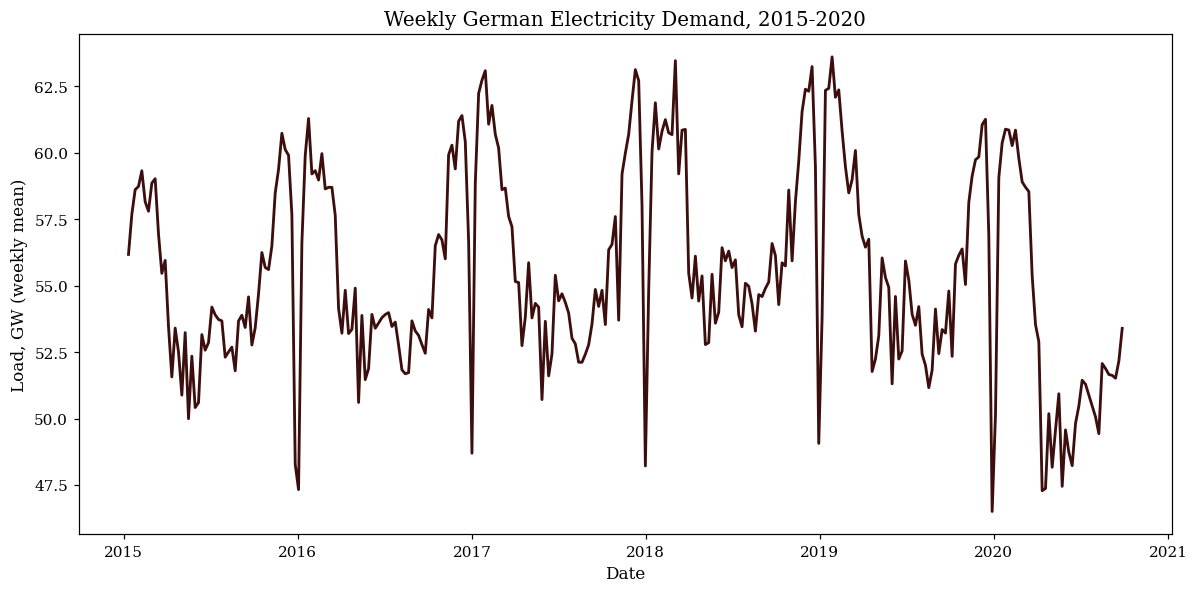

In [7]:
# 1.3  Weekly demand over the full window
fig, ax = plt.subplots()
ax.plot(weekly_gw.index, weekly_gw.values, color=PAL["actual"])
ax.set_title(T("weekly German electricity demand, 2015-2020"))
ax.set_xlabel("Date"); ax.set_ylabel(YLAB_WEEKLY)
plt.tight_layout(); plt.show()


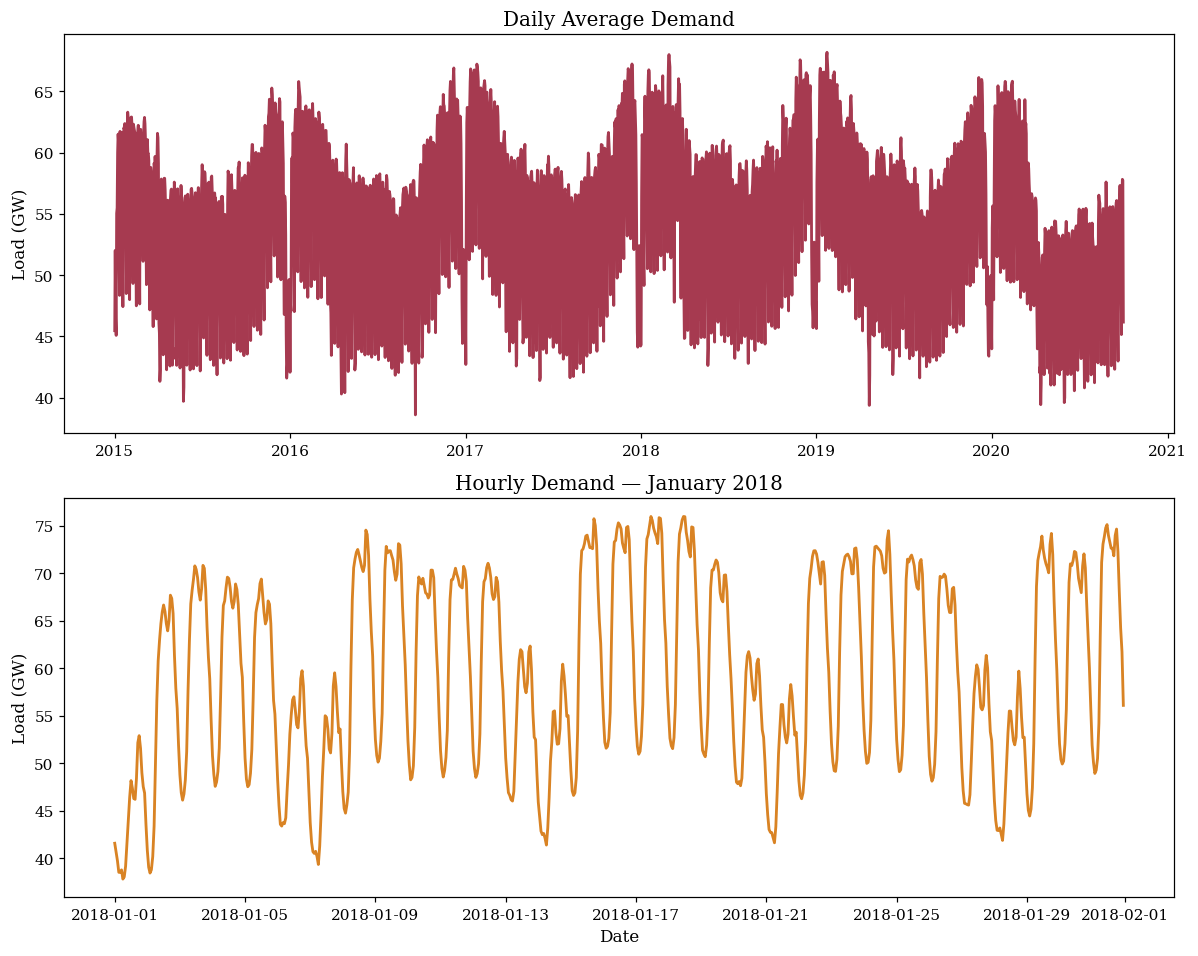

In [8]:
# 1.4  Daily series and a one-month hourly window (sub-weekly structure)
fig, axes = plt.subplots(2, 1, figsize=(FIGW, FIGH*1.6))
axes[0].plot(daily_gw.index, daily_gw.values, color=PAL["accents"][0])
axes[0].set_title(T("daily average demand")); axes[0].set_ylabel("Load (GW)")

one_month = hourly_gw.loc["2018-01-01":"2018-01-31"]
axes[1].plot(one_month.index, one_month.values, color=PAL["accents"][1])
axes[1].set_title(T("hourly demand — January 2018")); axes[1].set_ylabel("Load (GW)")
axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()


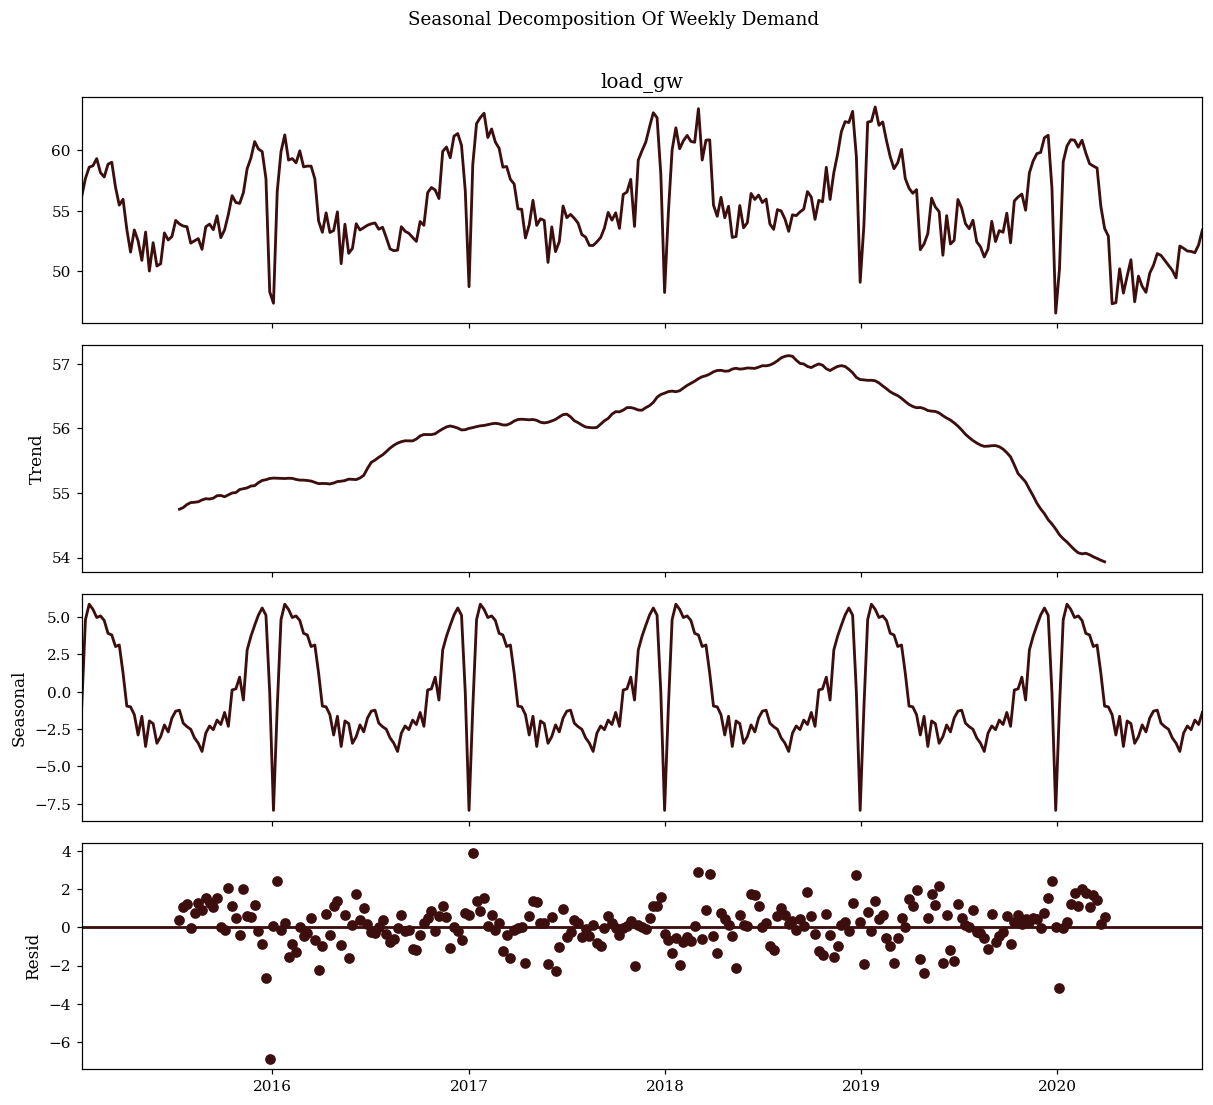

In [9]:
# 1.5  Seasonal decomposition (annual period = 52 weeks)
from statsmodels.tsa.seasonal import seasonal_decompose

dec = seasonal_decompose(weekly_gw.dropna(), model="additive", period=52)
fig = dec.plot()
fig.set_size_inches(FIGW, FIGH*1.8)
for a in fig.axes:
    for ln in a.get_lines():
        ln.set_color(PAL["actual"])
fig.suptitle(T("seasonal decomposition of weekly demand"), y=1.01)
plt.tight_layout(); plt.show()


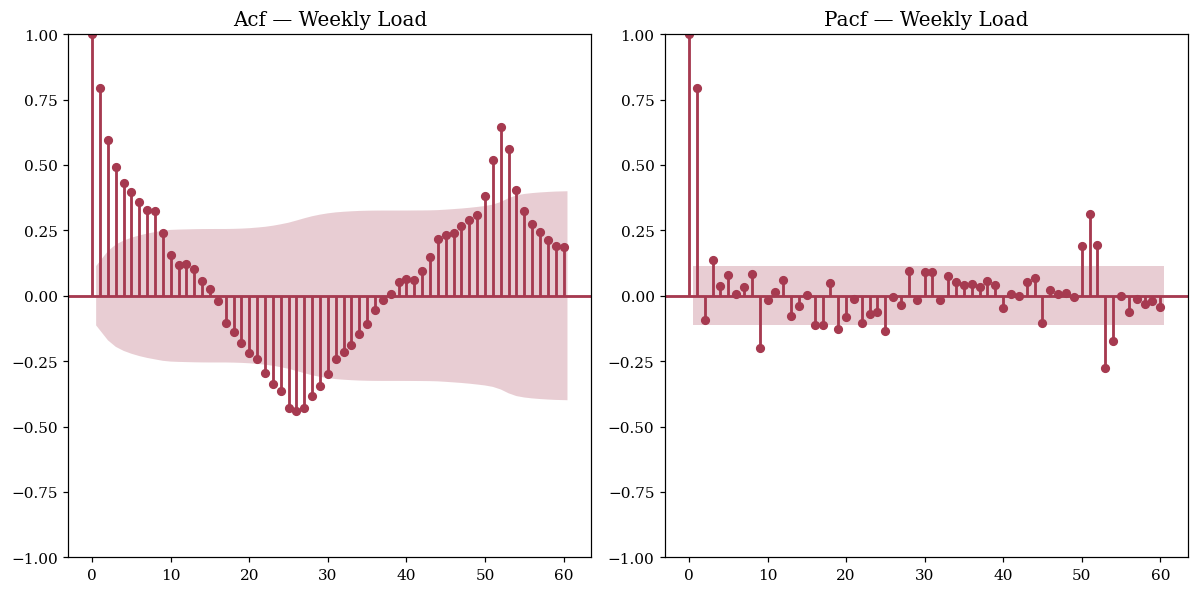

In [10]:
# 1.6  ACF and PACF of the weekly series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(FIGW, FIGH))
plot_acf(weekly_gw.dropna(),  lags=60, ax=axes[0])
plot_pacf(weekly_gw.dropna(), lags=60, ax=axes[1], method="ywm")
axes[0].set_title(T("ACF — weekly load"))
axes[1].set_title(T("PACF — weekly load"))
plt.tight_layout(); plt.show()


In [11]:
# 1.7  Augmented Dickey-Fuller helper + test on the level series
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    s = series.dropna()
    res = adfuller(s, autolag="AIC")           # robust to statsmodels return length
    stat, p, lags, nobs, crit = res[0], res[1], res[2], res[3], res[4]
    verdict = "stationary (reject H0)" if p < 0.05 else "non-stationary (fail to reject H0)"
    print("ADF  --  %s" % label)
    print("  statistic : %.4f" % stat)
    print("  p-value   : %.4g" % p)
    print("  lags/nobs : %d / %d" % (lags, nobs))
    for k, v in crit.items():
        print("  crit %-4s : %.4f" % (k, v))
    print("  =>", verdict)
    print()
    return p

_ = adf_report(weekly_gw, "level (weekly load)")


ADF  --  level (weekly load)
  statistic : -3.8909
  p-value   : 0.002103
  lags/nobs : 8 / 290
  crit 1%   : -3.4531
  crit 5%   : -2.8716
  crit 10%  : -2.5721
  => stationary (reject H0)



ADF  --  first difference  (d=1)
  statistic : -7.0507
  p-value   : 5.537e-10
  lags/nobs : 7 / 290
  crit 1%   : -3.4531
  crit 5%   : -2.8716
  crit 10%  : -2.5721
  => stationary (reject H0)

ADF  --  seasonal difference  (D=1, s=52)
  statistic : -1.8020
  p-value   : 0.3795
  lags/nobs : 11 / 235
  crit 1%   : -3.4585
  crit 5%   : -2.8739
  crit 10%  : -2.5734
  => non-stationary (fail to reject H0)

ADF  --  first + seasonal difference
  statistic : -7.7094
  p-value   : 1.276e-11
  lags/nobs : 10 / 235
  crit 1%   : -3.4585
  crit 5%   : -2.8739
  crit 10%  : -2.5734
  => stationary (reject H0)



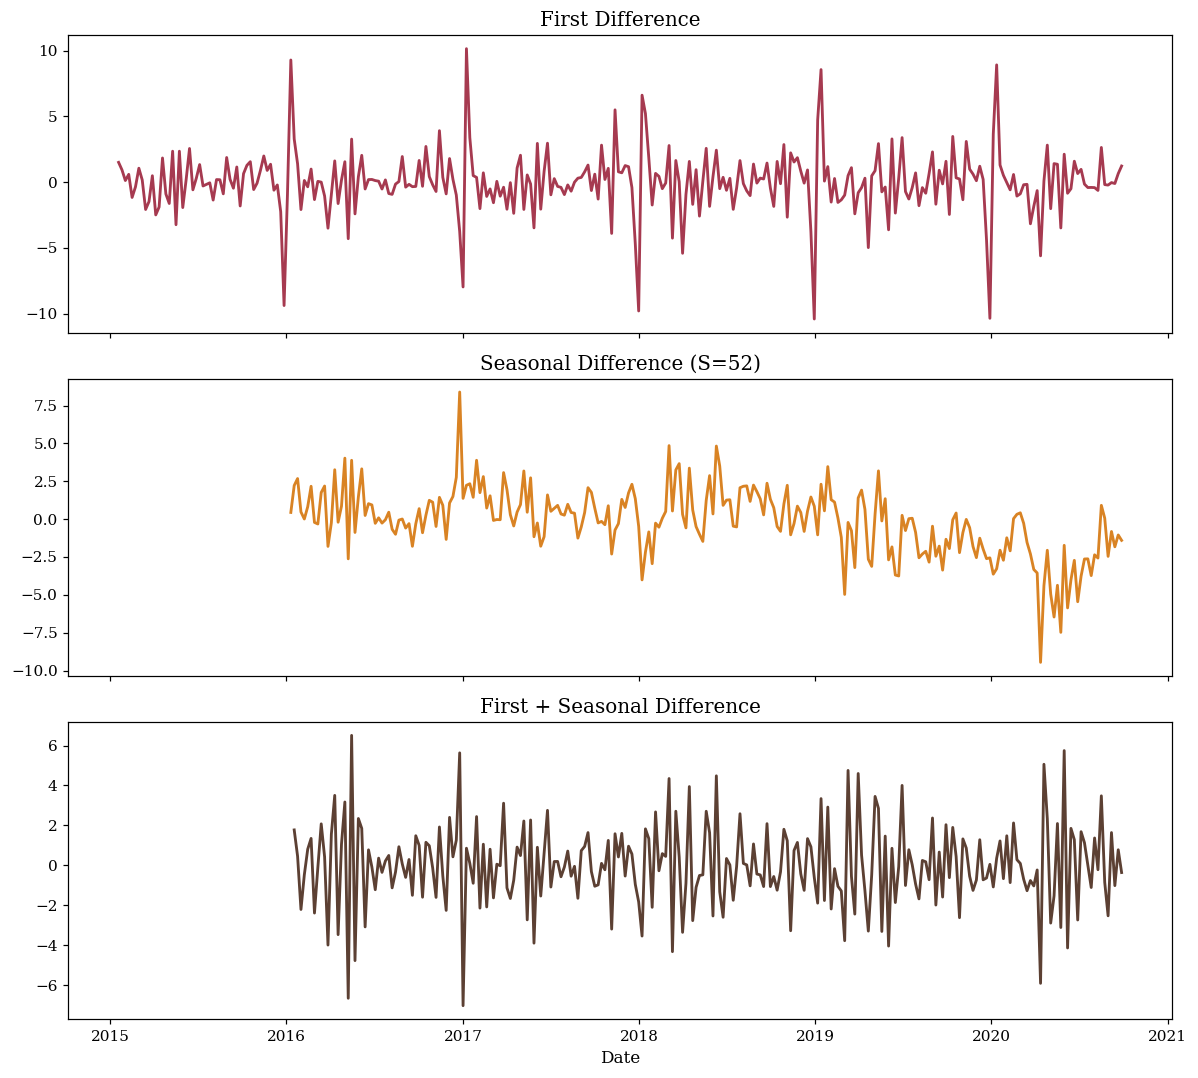

In [12]:
# 1.8  Differencing: first, seasonal (52), and both
d1    = weekly_gw.diff()
sdiff = weekly_gw.diff(52)
d1_s  = weekly_gw.diff().diff(52)

_ = adf_report(d1,    "first difference  (d=1)")
_ = adf_report(sdiff, "seasonal difference  (D=1, s=52)")
_ = adf_report(d1_s,  "first + seasonal difference")

fig, axes = plt.subplots(3, 1, figsize=(FIGW, FIGH*1.8), sharex=True)
axes[0].plot(d1.index,    d1.values,    color=PAL["accents"][0]); axes[0].set_title(T("first difference"))
axes[1].plot(sdiff.index, sdiff.values, color=PAL["accents"][1]); axes[1].set_title(T("seasonal difference (s=52)"))
axes[2].plot(d1_s.index,  d1_s.values,  color=PAL["accents"][2]); axes[2].set_title(T("first + seasonal difference"))
axes[2].set_xlabel("Date")
plt.tight_layout(); plt.show()


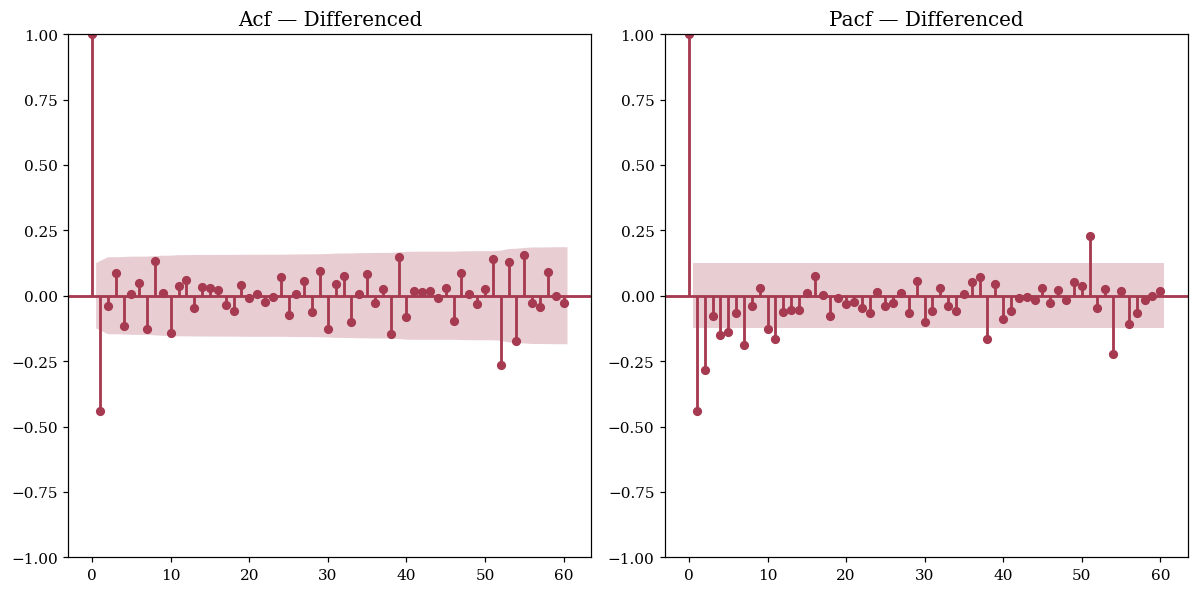

In [13]:
# 1.9  ACF and PACF of the first+seasonal differenced series
# These guide the ARMA orders (p,q) and seasonal orders (P,Q) for Section 3.
fig, axes = plt.subplots(1, 2, figsize=(FIGW, FIGH))
plot_acf(d1_s.dropna(),  lags=60, ax=axes[0]); axes[0].set_title(T("ACF — differenced"))
plot_pacf(d1_s.dropna(), lags=60, ax=axes[1], method="ywm"); axes[1].set_title(T("PACF — differenced"))
plt.tight_layout(); plt.show()


## Section 2 — Benchmark models  *(Part 2)*


In [14]:
# 2.1  Train/test split and the shared metric set
TEST_WEEKS = 104
SEASON = 52

y_train = weekly_gw.iloc[:-TEST_WEEKS]
y_test  = weekly_gw.iloc[-TEST_WEEKS:]
h = len(y_test)
print("train weeks:", len(y_train), "| test weeks:", h)
print("test window:", y_test.index.min().date(), "->", y_test.index.max().date())

# MASE scale = mean absolute error of an in-sample seasonal-naive forecast on train
_mase_scale = np.mean(np.abs(y_train.diff(SEASON).dropna().values))

def evaluate(name, y_true, y_pred):
    """Return MAE, RMSE, MASE and Bias for a forecast aligned to y_true."""
    e = np.asarray(y_true.values, float) - np.asarray(y_pred.values, float)
    mae  = np.mean(np.abs(e))
    rmse = np.sqrt(np.mean(e**2))
    mase = mae / _mase_scale
    bias = np.mean(e)
    return {"model": name, "MAE": mae, "RMSE": rmse, "MASE": mase, "Bias": bias}

# MASE scale is the in-sample seasonal-naive MAE; a perfect forecast scores 0.
assert abs(evaluate("perfect", y_test, y_test)["MASE"]) < 1e-9
print("metric self-check passed (perfect forecast MASE = 0)")


train weeks: 195 | test weeks: 104
test window: 2018-10-07 -> 2020-09-27
metric self-check passed (perfect forecast MASE = 0)


In [15]:
# 2.2  The four benchmark forecasts over the 104-week horizon
forecasts = {}          # name -> pd.Series aligned to y_test.index
metrics   = []          # list of metric dicts (weekly-scale models)

def _series(values):
    return pd.Series(np.asarray(values, float), index=y_test.index)

# mean: the training mean, repeated
forecasts["mean"] = _series(np.repeat(y_train.mean(), h))

# naive: the last observed value, repeated
forecasts["naive"] = _series(np.repeat(y_train.iloc[-1], h))

# seasonal naive: last 52 weeks tiled across the horizon
last_season = y_train.values[-SEASON:]
reps = int(np.ceil(h / SEASON))
forecasts["seasonal_naive"] = _series(np.tile(last_season, reps)[:h])

# drift: last value + average per-step change extrapolated forward
slope = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)
forecasts["drift"] = _series(y_train.iloc[-1] + slope * np.arange(1, h + 1))

for name in ["mean", "naive", "seasonal_naive", "drift"]:
    metrics.append(evaluate(name, y_test, forecasts[name]))

pd.DataFrame(metrics).round(3)


,model,MAE,RMSE,MASE,Bias
0,mean,3.788,4.401,2.799,-0.562
1,naive,3.857,4.476,2.850,-0.989
2,seasonal_naive,2.291,2.991,1.693,-1.748
3,drift,3.853,4.470,2.847,-0.978


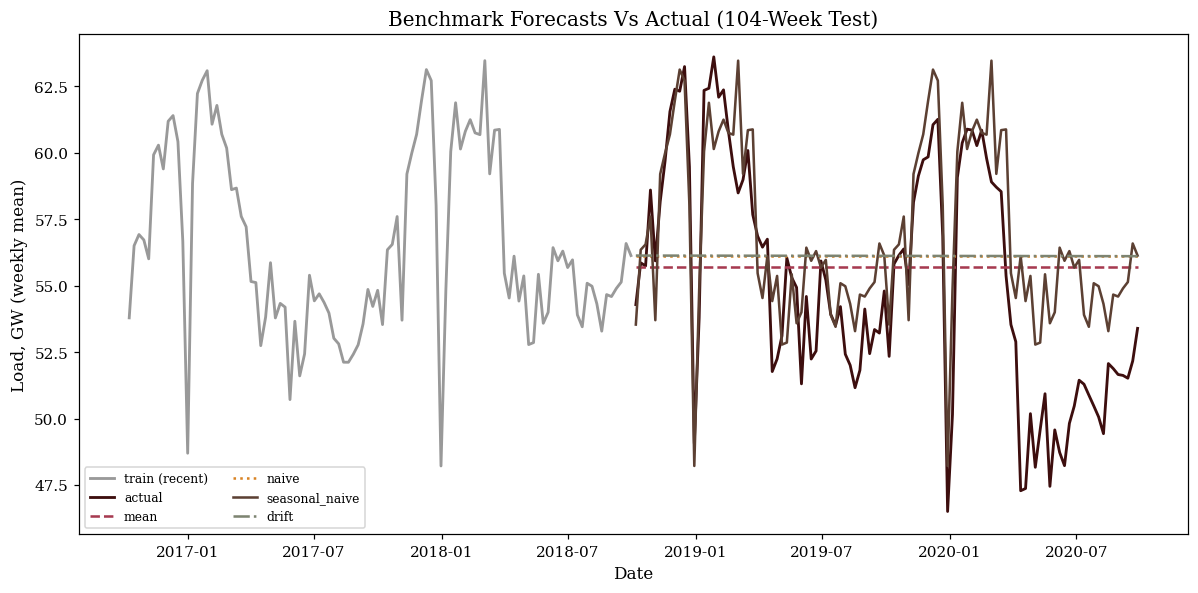

In [16]:
# 2.3  Plot the benchmark forecasts against the actual test series
fig, ax = plt.subplots()
ax.plot(y_train.index[-104:], y_train.values[-104:], color="0.6", label="train (recent)")
ax.plot(y_test.index, y_test.values, color=PAL["actual"], label="actual")
styles = {"mean": "--", "naive": ":", "seasonal_naive": "-", "drift": "-."}
for name, col in zip(["mean","naive","seasonal_naive","drift"], PAL["accents"]):
    ax.plot(y_test.index, forecasts[name].values, color=col, lw=LW*0.9,
            ls=styles[name], label=name)
ax.set_title(T("benchmark forecasts vs actual (104-week test)"))
ax.set_xlabel("Date"); ax.set_ylabel(YLAB_WEEKLY); ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()


## Section 3  SARIMA  *(Part 3)*


In [17]:
# 3.1  AIC grid search over the non-seasonal orders
from statsmodels.tsa.statespace.sarimax import SARIMAX

FAST = False                       # full brief grid (p,q in [0,6]); True = quick check
p_max = 3 if FAST else 6
q_max = 3 if FAST else 6
SEASONAL_ORDER = (1, 1, 1, SEASON) # compact seasonal part with annual period

search = []
for p in range(0, p_max + 1):
    for d in range(0, 3):
        for q in range(0, q_max + 1):
            try:
                m = SARIMAX(y_train, order=(p, d, q),
                            seasonal_order=SEASONAL_ORDER,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
                r = m.fit(disp=False)
                search.append(((p, d, q), r.aic))
            except Exception:
                continue

search.sort(key=lambda t: t[1])
best_order = search[0][0]
print("fits that converged:", len(search))
print("best (p,d,q) by AIC:", best_order, "| AIC = %.2f" % search[0][1])
print("top 5:")
for od, aic in search[:5]:
    print("   ", od, "AIC = %.2f" % aic)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

fits that converged: 147
best (p,d,q) by AIC: (1, 1, 6) | AIC = 297.54
top 5:
    (1, 1, 6) AIC = 297.54
    (0, 1, 6) AIC = 299.10
    (3, 1, 6) AIC = 299.28
    (2, 1, 6) AIC = 299.39
    (2, 0, 6) AIC = 300.60


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  195
Model:             SARIMAX(1, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -138.769
Date:                              Wed, 01 Jul 2026   AIC                            297.538
Time:                                      21:55:09   BIC                            321.726
Sample:                                  01-11-2015   HQIC                           307.256
                                       - 09-30-2018                                         
Covariance Type:                                opg                                         


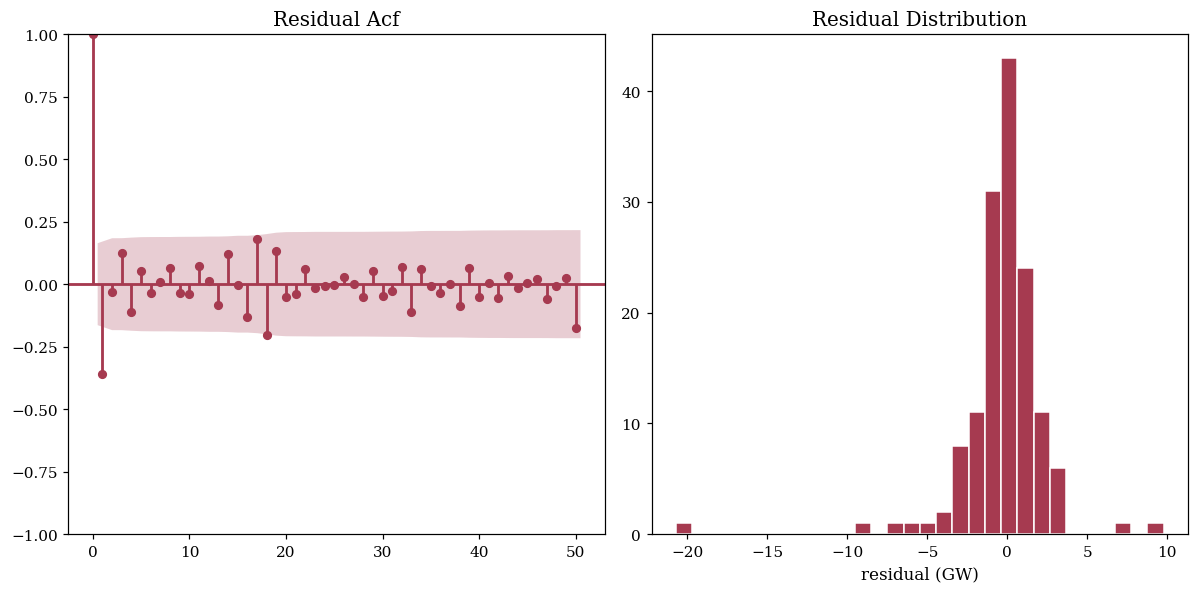

Ljung-Box (H0 = residuals are white noise):
    lb_stat  lb_pvalue
12  25.8593     0.0112
24  48.8599     0.0020
52  72.0571     0.0342


In [18]:
# 3.2  Fit the chosen SARIMA and inspect residuals
sarima_fit = SARIMAX(y_train, order=best_order, seasonal_order=SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sarima_fit.summary().tables[0])

resid = sarima_fit.resid.iloc[SEASON:]     # drop the burn-in from differencing
fig, axes = plt.subplots(1, 2, figsize=(FIGW, FIGH))
plot_acf(resid, lags=50, ax=axes[0]); axes[0].set_title(T("residual ACF"))
axes[1].hist(resid, bins=30, color=PAL["accents"][0], edgecolor="white")
axes[1].set_title(T("residual distribution")); axes[1].set_xlabel("residual (GW)")
plt.tight_layout(); plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[12, 24, 52], return_df=True)
print("Ljung-Box (H0 = residuals are white noise):")
print(lb.round(4))


SARIMA test RMSE: 4.029 GW | MASE: 2.437


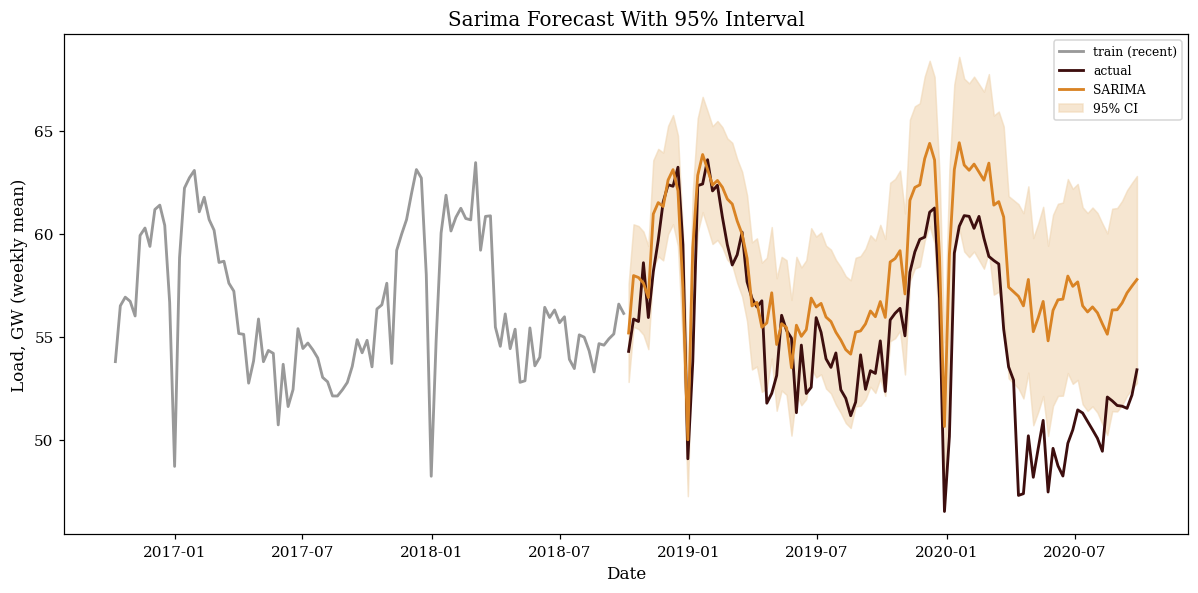

In [19]:
# 3.3  Forecast the 104-week test window with confidence intervals
sarima_fc  = sarima_fit.get_forecast(steps=h)
sarima_mean = sarima_fc.predicted_mean
sarima_mean.index = y_test.index
sarima_ci = sarima_fc.conf_int(alpha=0.05)
sarima_ci.index = y_test.index

forecasts["sarima"] = sarima_mean
metrics.append(evaluate("sarima", y_test, sarima_mean))
print("SARIMA test RMSE: %.3f GW | MASE: %.3f" % (metrics[-1]["RMSE"], metrics[-1]["MASE"]))

fig, ax = plt.subplots()
ax.plot(y_train.index[-104:], y_train.values[-104:], color="0.6", label="train (recent)")
ax.plot(y_test.index, y_test.values, color=PAL["actual"], label="actual")
ax.plot(y_test.index, sarima_mean.values, color=PAL["forecast"], label="SARIMA")
ax.fill_between(y_test.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                color=PAL["ci"], alpha=0.6, label="95% CI")
ax.set_title(T("SARIMA forecast with 95% interval"))
ax.set_xlabel("Date"); ax.set_ylabel(YLAB_WEEKLY); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Section 4  SARIMAX with temperature  *(Part 4)*


In [20]:
# 4.1  Download Berlin daily temperature and build weekly features
import requests

def get_berlin_temperature(start="2015-01-01", end="2020-12-31"):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {"latitude": 52.52, "longitude": 13.41,
              "start_date": start, "end_date": end,
              "daily": "temperature_2m_mean", "timezone": "Europe/Berlin"}
    r = requests.get(url, params=params, timeout=60); r.raise_for_status()
    d = r.json()["daily"]
    s = pd.Series(d["temperature_2m_mean"], index=pd.to_datetime(d["time"]), name="temp")
    return s

temp_daily = get_berlin_temperature(end=str(weekly_gw.index.max().date()))
print("temperature days:", len(temp_daily), "| range:", temp_daily.index.min().date(),
      "->", temp_daily.index.max().date())

# heating/cooling degree-day bases (defensible standard values)
HDD_BASE, CDD_BASE = 15.5, 22.0
tw = pd.DataFrame(index=weekly_gw.index)
tw["temp_mean"] = temp_daily.resample("W").mean().reindex(weekly_gw.index)
tw["temp_min"]  = temp_daily.resample("W").min().reindex(weekly_gw.index)
tw["temp_max"]  = temp_daily.resample("W").max().reindex(weekly_gw.index)
tw["heating_degree"] = np.maximum(HDD_BASE - temp_daily, 0).resample("W").sum().reindex(weekly_gw.index)
tw["cooling_degree"] = np.maximum(temp_daily - CDD_BASE, 0).resample("W").sum().reindex(weekly_gw.index)
tw = tw.interpolate("time").bfill().ffill()
tw.head()


temperature days: 2097 | range: 2015-01-01 -> 2020-09-27


,temp_mean,temp_min,temp_max,heating_degree,cooling_degree
utc_timestamp,,,,,
2015-01-11,3.885714,1.2,8.5,81.3,0.0
2015-01-18,4.900000,-0.8,9.2,74.2,0.0
2015-01-25,0.028571,-0.7,0.9,108.3,0.0
2015-02-01,1.414286,-0.1,2.8,98.6,0.0
2015-02-08,-1.228571,-2.6,0.7,117.1,0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX (temp) test RMSE: 3.873 GW | MASE: 2.274


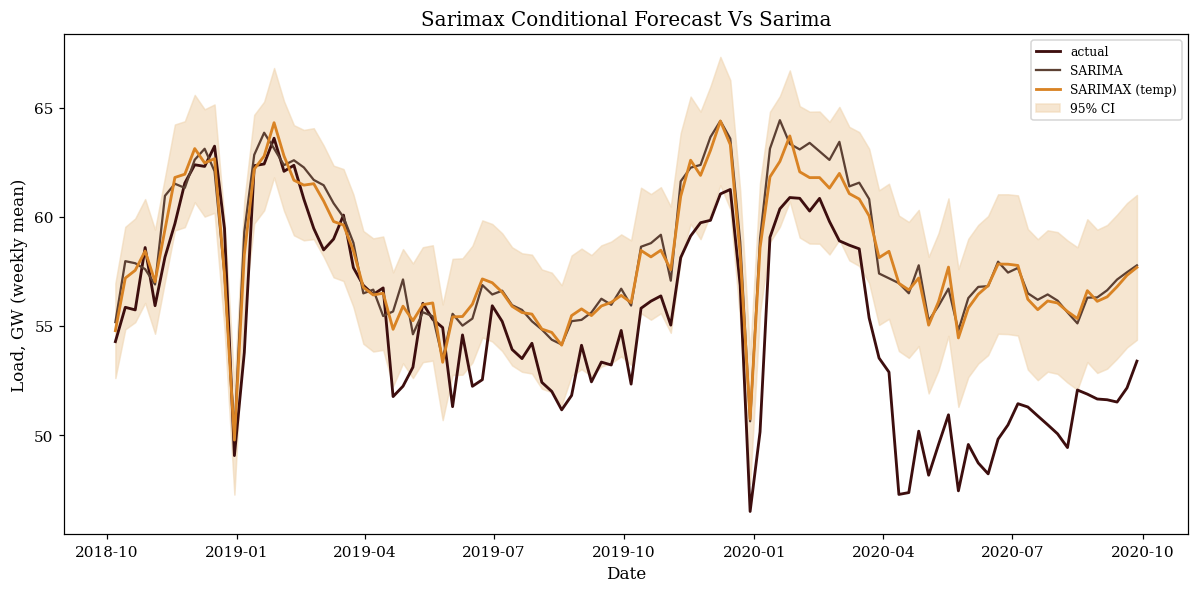

In [21]:
# 4.2  Fit SARIMAX with temperature exog and forecast (conditional)
exog_cols = ["temp_mean", "heating_degree", "cooling_degree"]
X = tw[exog_cols]
X_train, X_test = X.iloc[:-TEST_WEEKS], X.iloc[-TEST_WEEKS:]

# no explicit trend term: with d=1 and D=1 a constant is not identifiable, and
# leaving it out keeps SARIMA and SARIMAX directly comparable.
sarimax_fit = SARIMAX(y_train, exog=X_train, order=best_order,
                      seasonal_order=SEASONAL_ORDER,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

sarimax_fc = sarimax_fit.get_forecast(steps=h, exog=X_test)
sarimax_mean = sarimax_fc.predicted_mean; sarimax_mean.index = y_test.index
sarimax_ci = sarimax_fc.conf_int(alpha=0.05); sarimax_ci.index = y_test.index

forecasts["sarimax"] = sarimax_mean
metrics.append(evaluate("sarimax", y_test, sarimax_mean))
print("SARIMAX (temp) test RMSE: %.3f GW | MASE: %.3f"
      % (metrics[-1]["RMSE"], metrics[-1]["MASE"]))

fig, ax = plt.subplots()
ax.plot(y_test.index, y_test.values, color=PAL["actual"], label="actual")
ax.plot(y_test.index, sarima_mean.values, color=PAL["accents"][2], lw=LW*0.8, label="SARIMA")
ax.plot(y_test.index, sarimax_mean.values, color=PAL["forecast"], label="SARIMAX (temp)")
ax.fill_between(y_test.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                color=PAL["ci"], alpha=0.6, label="95% CI")
ax.set_title(T("SARIMAX conditional forecast vs SARIMA"))
ax.set_xlabel("Date"); ax.set_ylabel(YLAB_WEEKLY); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Section 5  Feature-based ML  *(Part 5)*

In [22]:
# 5.0  Install the holidays package (Colab does not ship it by default)
!pip install holidays -q


In [23]:
# 5.1  Build a leak-free feature table (calendar + holiday + temperature + lags)
import holidays as pyholidays

de_holidays = pyholidays.Germany(years=range(2014, 2022))

def build_features(y, temp_df):
    df = pd.DataFrame(index=y.index)
    df["load_gw"] = y
    # calendar
    wk = y.index.isocalendar().week.astype(int)
    df["woy_sin"] = np.sin(2*np.pi*wk/52.0)
    df["woy_cos"] = np.cos(2*np.pi*wk/52.0)
    df["month"]   = y.index.month
    # holidays: count of public-holiday days in each week
    df["holiday_days"] = [sum((d.date() in de_holidays)
                              for d in pd.date_range(ts - pd.Timedelta(days=6), ts))
                          for ts in y.index]
    # temperature (known-at-origin only as a conditional covariate)
    df = df.join(temp_df[["temp_mean", "heating_degree", "cooling_degree"]])
    # lags and rolling means of the TARGET, shifted -> past only
    for L in (1, 2, 4, 52):
        df["lag_%d" % L] = y.shift(L)
    df["roll4"]  = y.shift(1).rolling(4).mean()
    df["roll8"]  = y.shift(1).rolling(8).mean()
    return df

feat = build_features(weekly_gw, tw)
feat_model = feat.dropna()
FEATURES = [c for c in feat_model.columns if c != "load_gw"]
print("feature rows:", len(feat_model), "| n features:", len(FEATURES))
print(FEATURES)


feature rows: 247 | n features: 13
['woy_sin', 'woy_cos', 'month', 'holiday_days', 'temp_mean', 'heating_degree', 'cooling_degree', 'lag_1', 'lag_2', 'lag_4', 'lag_52', 'roll4', 'roll8']


In [24]:
# 5.2  Train RF and Gradient Boosting on the pre-test rows
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

train_mask = feat_model.index <= y_train.index.max()
Xtr, ytr = feat_model.loc[train_mask, FEATURES], feat_model.loc[train_mask, "load_gw"]

rf = RandomForestRegressor(n_estimators=400, max_depth=None,
                           min_samples_leaf=2, random_state=SEED, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=400, max_depth=3,
                               learning_rate=0.05, random_state=SEED)
rf.fit(Xtr, ytr); gb.fit(Xtr, ytr)
print("fitted RF and GB on", len(Xtr), "rows")


fitted RF and GB on 143 rows


  model    MAE   RMSE   MASE   Bias
0    rf  2.199  2.913  1.625 -1.717
1   gbr  2.190  2.922  1.619 -1.832


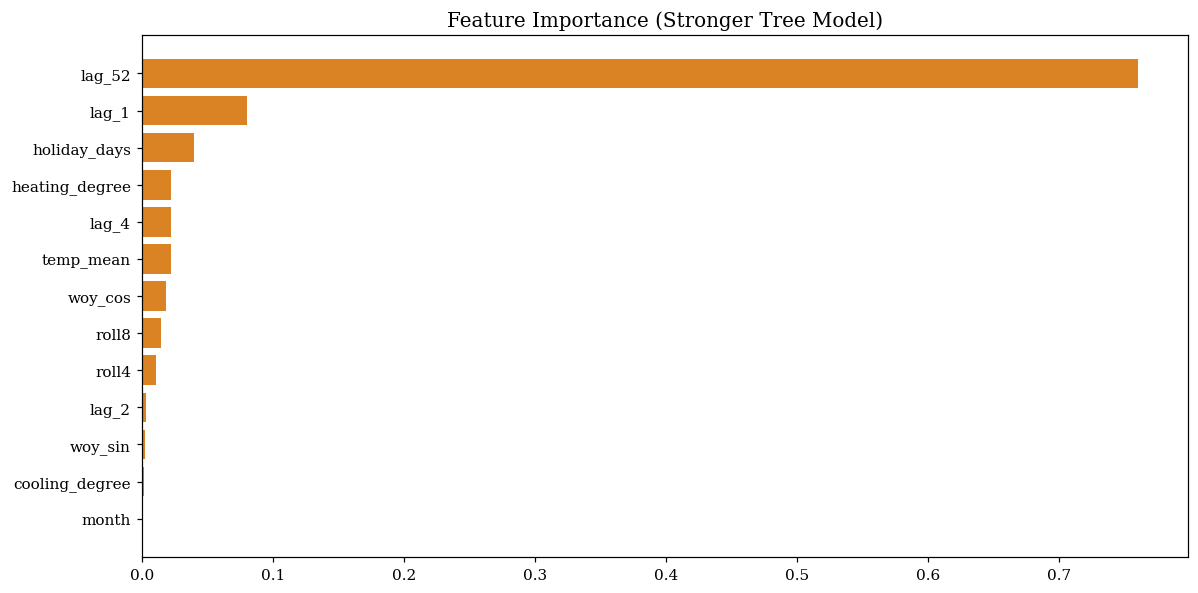

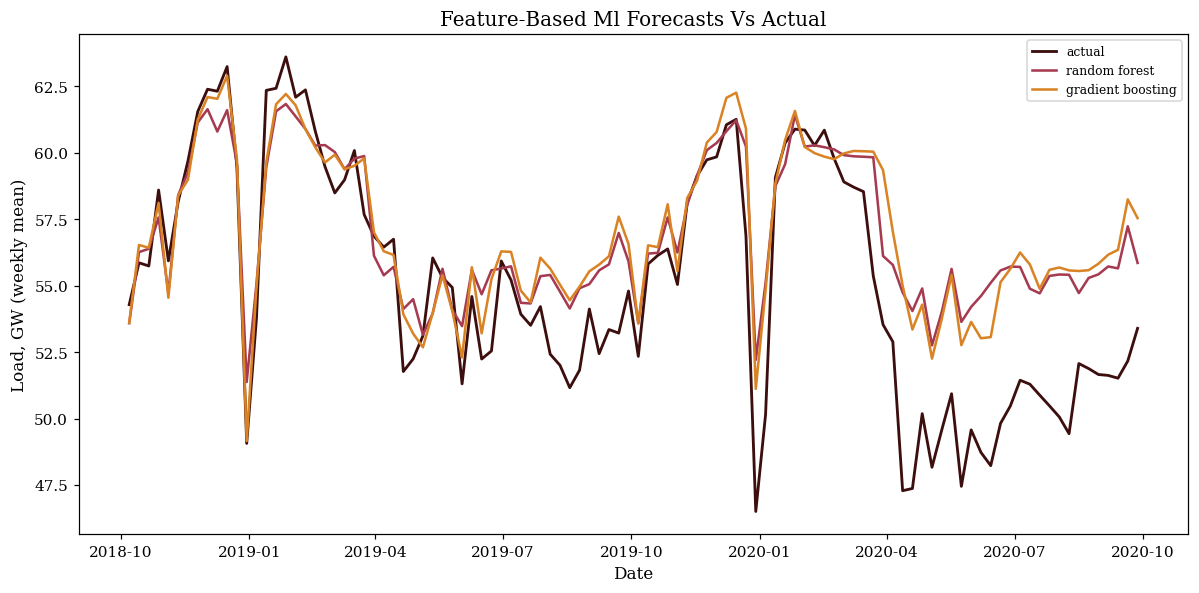

In [25]:
# 5.3  Recursive 104-week forecast (predicted weeks feed the next lags)
def recursive_forecast(model, y_hist, temp_df, index):
    hist = y_hist.copy()
    preds = []
    for ts in index:
        full = pd.concat([hist, pd.Series([np.nan], index=[ts])])
        row = build_features(full, temp_df).loc[[ts], FEATURES]
        yhat = float(model.predict(row)[0])
        preds.append(yhat)
        hist.loc[ts] = yhat            # append the prediction before the next step
    return pd.Series(preds, index=index)

rf_fc = recursive_forecast(rf, y_train, tw, y_test.index)
gb_fc = recursive_forecast(gb, y_train, tw, y_test.index)

forecasts["rf"] = rf_fc
forecasts["gbr"] = gb_fc
metrics.append(evaluate("rf", y_test, rf_fc))
metrics.append(evaluate("gbr", y_test, gb_fc))
print(pd.DataFrame(metrics[-2:]).round(3))

# feature importance of the stronger tree model
best_tree = gb if metrics[-1]["MASE"] < metrics[-2]["MASE"] else rf
imp = pd.Series(best_tree.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots()
ax.barh(imp.index, imp.values, color=PAL["accents"][1])
ax.set_title(T("feature importance (stronger tree model)"))
plt.tight_layout(); plt.show()

fig, ax = plt.subplots()
ax.plot(y_test.index, y_test.values, color=PAL["actual"], label="actual")
ax.plot(y_test.index, rf_fc.values, color=PAL["accents"][0], lw=LW*0.9, label="random forest")
ax.plot(y_test.index, gb_fc.values, color=PAL["forecast"], lw=LW*0.9, label="gradient boosting")
ax.set_title(T("feature-based ML forecasts vs actual"))
ax.set_xlabel("Date"); ax.set_ylabel(YLAB_WEEKLY); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Section 6 — LSTM on hourly data  *(Part 6)*

In [26]:
# 6.1  Prepare hourly sequences with train-only scaling
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED); np.random.seed(SEED)

LOOKBACK = 168                      # one week of hourly history
hourly = hourly_gw.copy()
split_time = y_test.index.min()     # same 2-year boundary as the weekly models
train_h = hourly[hourly.index < split_time]
test_h  = hourly[hourly.index >= split_time]
print("hourly train:", len(train_h), "| hourly test:", len(test_h))

# scale using TRAIN statistics only
mu, sigma = train_h.mean(), train_h.std()
scaled = (hourly - mu) / sigma

def make_sequences(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i]); y.append(arr[i])
    return np.array(X)[..., None], np.array(y)

train_arr = scaled[scaled.index < split_time].values
Xtr_h, ytr_h = make_sequences(train_arr, LOOKBACK)
print("train sequences:", Xtr_h.shape)


hourly train: 32998 | hourly test: 17402
train sequences: (32830, 168, 1)


units=32 dropout=0.1 lr=1e-03 -> best val_loss 0.01131
units=48 dropout=0.2 lr=1e-03 -> best val_loss 0.00595
units=64 dropout=0.2 lr=5e-04 -> best val_loss 0.01171
best config: {'units': 48, 'dropout': 0.2, 'lr': 0.001}


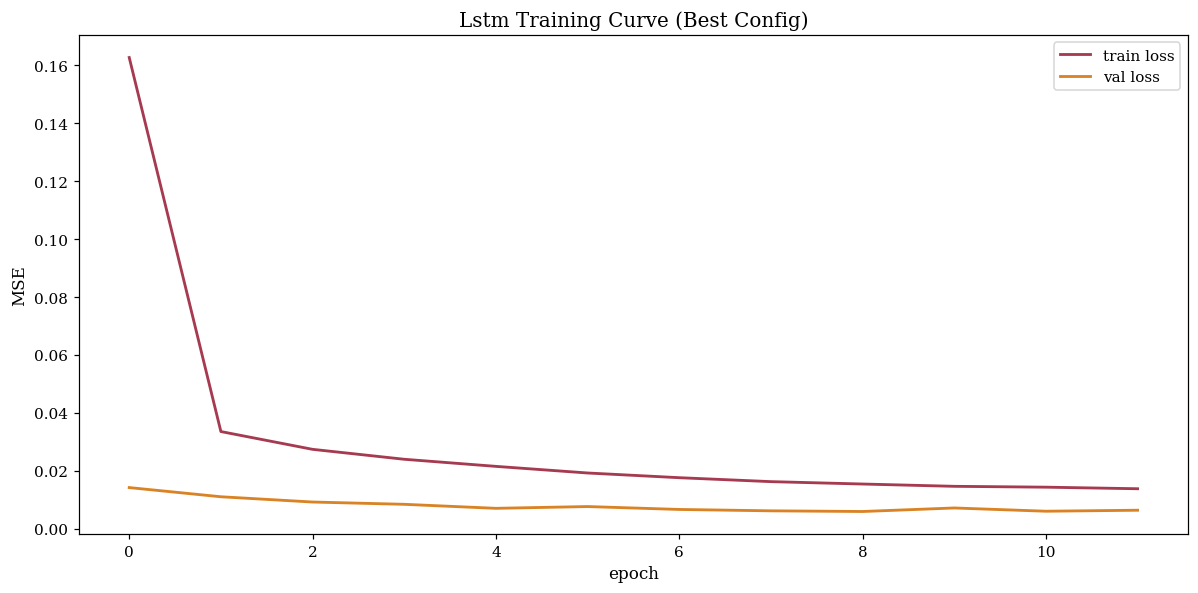

In [27]:
# 6.2  Small hyperparameter sweep, then train the best LSTM (early stopping)
def build_lstm(units, dropout, lr):
    net = Sequential([
        Input(shape=(LOOKBACK, 1)),
        LSTM(units, return_sequences=False),
        Dropout(dropout),
        Dense(24, activation="relu"),
        Dense(1),
    ])
    net.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return net

# a compact manual sweep over units / dropout / learning rate
grid = [(32, 0.1, 1e-3), (48, 0.2, 1e-3), (64, 0.2, 5e-4)]
es = EarlyStopping(patience=3, restore_best_weights=True, monitor="val_loss")

sweep = []
for units, dropout, lr in grid:
    net = build_lstm(units, dropout, lr)
    hfit = net.fit(Xtr_h, ytr_h, validation_split=0.1, epochs=15,
                   batch_size=128, callbacks=[es], verbose=0)
    val = min(hfit.history["val_loss"])
    sweep.append({"units": units, "dropout": dropout, "lr": lr,
                  "val_loss": val, "model": net, "history": hfit})
    print("units=%d dropout=%.1f lr=%.0e -> best val_loss %.5f" % (units, dropout, lr, val))

best_cfg = min(sweep, key=lambda d: d["val_loss"])
model = best_cfg["model"]; hist_fit = best_cfg["history"]
print("best config:", {k: best_cfg[k] for k in ("units", "dropout", "lr")})

fig, ax = plt.subplots()
ax.plot(hist_fit.history["loss"], color=PAL["accents"][0], label="train loss")
ax.plot(hist_fit.history["val_loss"], color=PAL["forecast"], label="val loss")
ax.set_title(T("LSTM training curve (best config)")); ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.legend(); plt.tight_layout(); plt.show()


LSTM recursive multi-step (weekly-agg) RMSE: 5.601 GW | MASE: 3.280


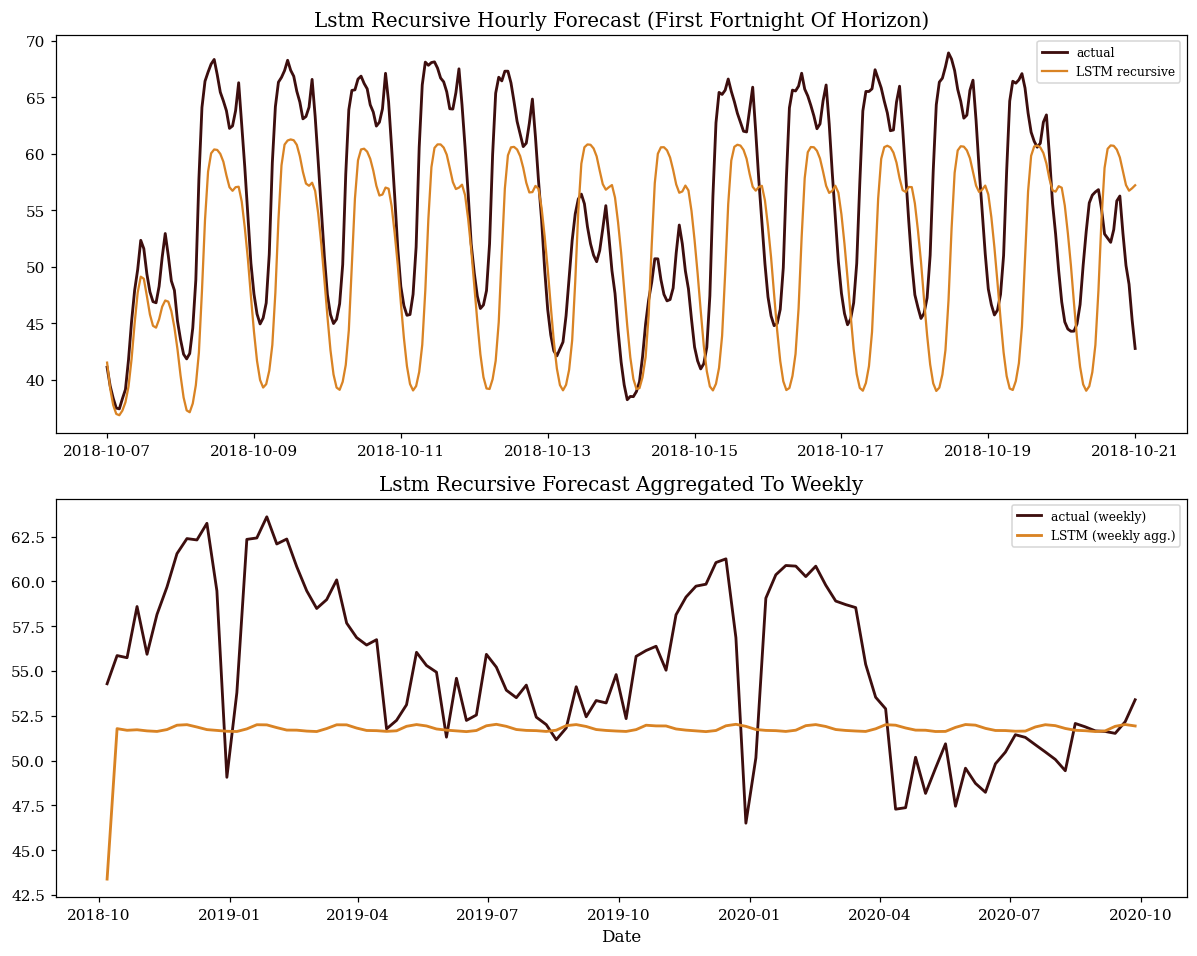

In [30]:
# 6.3  Genuine recursive multi-step forecast over the 2-year test window.
# Seed with the last look-back of TRAIN; feed each prediction back in. No test
# actual is used, so this is a true ahead-forecast. It rolls ~17k hourly steps
# and takes a few minutes.
test_index_h = scaled.index[scaled.index >= split_time]
buf = list(train_arr[-LOOKBACK:])          # last look-back window of training (scaled)
preds_scaled = []
for _ in range(len(test_index_h)):
    x = np.asarray(buf[-LOOKBACK:], dtype=np.float32).reshape(1, LOOKBACK, 1)
    yhat = float(model(x, training=False).numpy().ravel()[0])
    preds_scaled.append(yhat)
    buf.append(yhat)

pred_hourly = pd.Series(np.array(preds_scaled) * sigma + mu, index=test_index_h)

# aggregate the hourly forecast to weekly means for a like-for-like comparison
lstm_weekly = pred_hourly.resample("W").mean().reindex(y_test.index)
lstm_weekly = lstm_weekly.interpolate().bfill().ffill()
forecasts["lstm"] = lstm_weekly
metrics.append(evaluate("lstm", y_test, lstm_weekly))
print("LSTM recursive multi-step (weekly-agg) RMSE: %.3f GW | MASE: %.3f"
      % (metrics[-1]["RMSE"], metrics[-1]["MASE"]))

fig, axes = plt.subplots(2, 1, figsize=(FIGW, FIGH*1.6))
win = pred_hourly.loc[:pred_hourly.index[0] + pd.Timedelta(days=14)]

# Fix: Ensure hourly_gw index is unique before reindexing
if not hourly_gw.index.is_unique:
    hourly_gw_unique = hourly_gw[~hourly_gw.index.duplicated(keep='first')]
else:
    hourly_gw_unique = hourly_gw

axes[0].plot(win.index, hourly_gw_unique.reindex(win.index).values, color=PAL["actual"], label="actual")
axes[0].plot(win.index, win.values, color=PAL["forecast"], lw=LW*0.8, label="LSTM recursive")
axes[0].set_title(T("LSTM recursive hourly forecast (first fortnight of horizon)")); axes[0].legend(fontsize=8)
axes[1].plot(y_test.index, y_test.values, color=PAL["actual"], label="actual (weekly)")
axes[1].plot(y_test.index, lstm_weekly.values, color=PAL["forecast"], label="LSTM (weekly agg.)")
axes[1].set_title(T("LSTM recursive forecast aggregated to weekly")); axes[1].set_xlabel("Date"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Section 7 — Analysis questions  *(Part 7)*


In [31]:
# 7.1  Evidence table: every model vs the seasonal-naive benchmark
comp = pd.DataFrame(metrics).drop_duplicates("model", keep="last").set_index("model")
sn = comp.loc["seasonal_naive"]
comp["MASE_vs_snaive"] = comp["MASE"] / sn["MASE"]
comp["RMSE_vs_snaive_%"] = 100 * (comp["RMSE"] / sn["RMSE"] - 1)
comp_sorted = comp.sort_values("MASE")
print("Lower MASE = better; MASE_vs_snaive < 1 beats seasonal naive.")
comp_sorted.round(3)


Lower MASE = better; MASE_vs_snaive < 1 beats seasonal naive.


,MAE,RMSE,MASE,Bias,MASE_vs_snaive,RMSE_vs_snaive_%
model,,,,,,
gbr,2.190,2.922,1.619,-1.832,0.956,-2.329
rf,2.199,2.913,1.625,-1.717,0.960,-2.608
seasonal_naive,2.291,2.991,1.693,-1.748,1.000,0.000
sarimax,3.077,3.873,2.274,-2.960,1.343,29.473
sarima,3.298,4.029,2.437,-3.134,1.439,34.675
mean,3.788,4.401,2.799,-0.562,1.653,47.122
drift,3.853,4.470,2.847,-0.978,1.681,49.421
naive,3.857,4.476,2.850,-0.989,1.684,49.620
lstm,4.438,5.601,3.280,3.439,1.937,87.230


## Section 8  Consolidated comparison  *(Part 8)*



In [32]:
# 8.1  Final metric table (sorted by MASE) and save outputs
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

final_metrics = pd.DataFrame(metrics).drop_duplicates("model", keep="last").sort_values("MASE")
final_metrics.to_csv("outputs/metrics/model_comparison.csv", index=False)

fc_df = pd.DataFrame({"actual": y_test})
for name, s in forecasts.items():
    fc_df[name] = s.reindex(y_test.index)
fc_df.to_csv("outputs/forecasts/all_forecasts.csv")
final_metrics.round(3)


,model,MAE,RMSE,MASE,Bias
7,gbr,2.190,2.922,1.619,-1.832
6,rf,2.199,2.913,1.625,-1.717
2,seasonal_naive,2.291,2.991,1.693,-1.748
5,sarimax,3.077,3.873,2.274,-2.960
4,sarima,3.298,4.029,2.437,-3.134
0,mean,3.788,4.401,2.799,-0.562
3,drift,3.853,4.470,2.847,-0.978
1,naive,3.857,4.476,2.850,-0.989
10,lstm,4.438,5.601,3.280,3.439


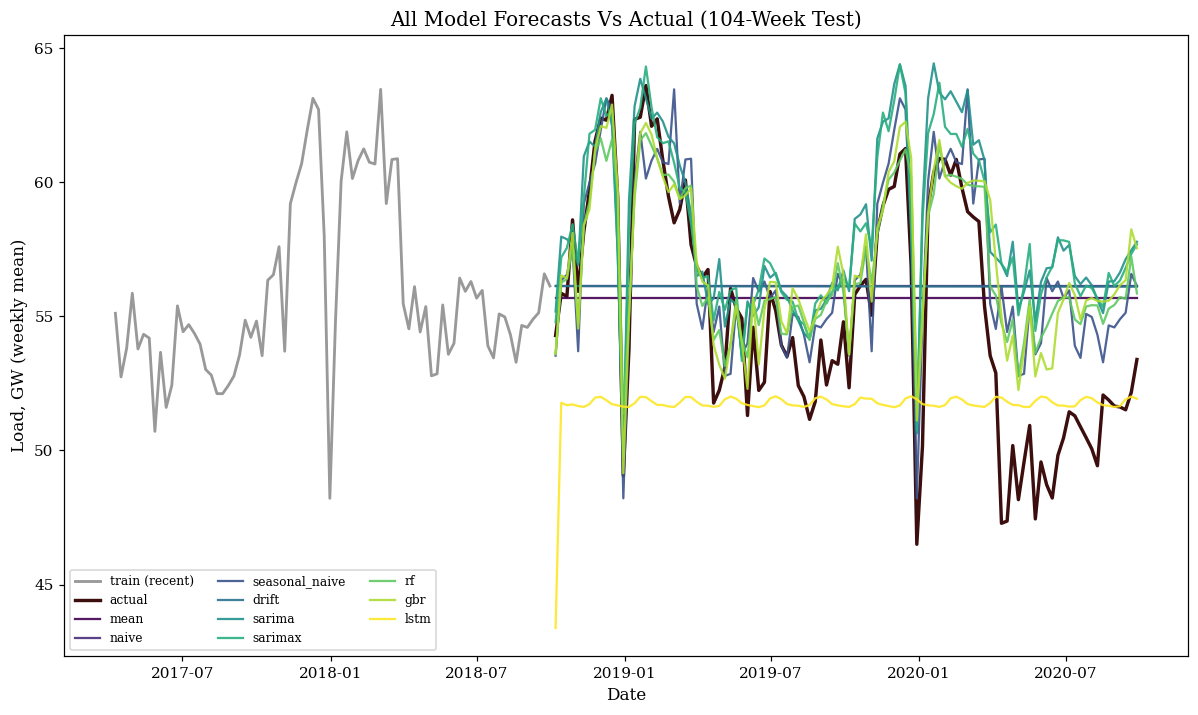

Saved metrics, forecasts and the comparison figure under outputs/.


In [33]:
# 8.2  Master forecast plot: all models vs actual
fig, ax = plt.subplots(figsize=(FIGW, FIGH*1.2))
ax.plot(y_train.index[-78:], y_train.values[-78:], color="0.6", label="train (recent)")
ax.plot(y_test.index, y_test.values, color=PAL["actual"], lw=LW*1.2, label="actual")
order = list(forecasts.keys())
cmap = plt.cm.viridis(np.linspace(0, 1, len(order)))
for name, col in zip(order, cmap):
    ax.plot(y_test.index, forecasts[name].reindex(y_test.index).values,
            color=col, lw=LW*0.8, alpha=0.9, label=name)
ax.set_title(T("all model forecasts vs actual (104-week test)"))
ax.set_xlabel("Date"); ax.set_ylabel(YLAB_WEEKLY); ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig("outputs/figures/forecast_comparison.png", bbox_inches="tight")
plt.show()
print("Saved metrics, forecasts and the comparison figure under outputs/.")


Mean absolute error (GW) by regime:
                all_weeks_MAE  festive_MAE  coldest5_MAE  hottest5_MAE
seasonal_naive          2.291        1.926         1.291         1.539
sarima                  3.298        3.997         0.919         2.387
sarimax                 3.077        3.462         1.110         2.713
gbr                     2.190        2.241         0.605         2.648
lstm                    4.438        4.946        10.603         2.273


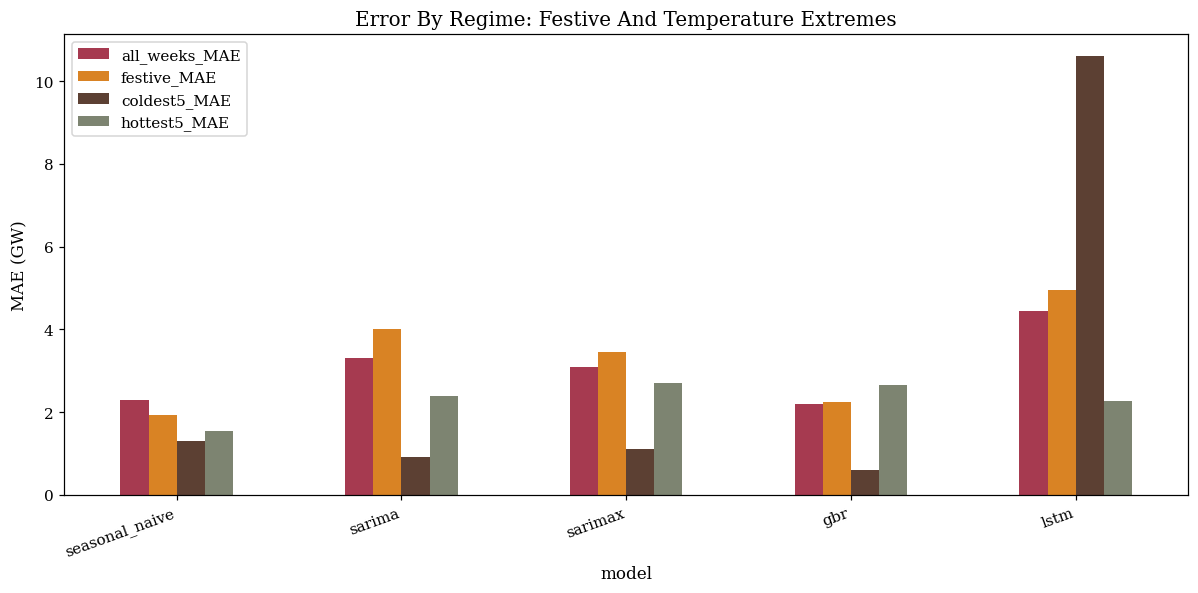

In [34]:
# 8.3  Targeted error diagnostics: Christmas/New Year and hot/cold weeks
key_models = [m for m in ["seasonal_naive", "sarima", "sarimax", "gbr", "lstm"]
              if m in forecasts]
abs_err = pd.DataFrame({m: (forecasts[m].reindex(y_test.index) - y_test).abs()
                        for m in key_models})

# Christmas / New Year weeks in the test window (ISO weeks 52, 1, 2)
iso_wk = y_test.index.isocalendar().week
festive = abs_err[iso_wk.isin([52, 1, 2]).values]

# hottest and coldest test weeks, from the weekly mean temperature
temp_test = tw["temp_mean"].reindex(y_test.index)
cold = abs_err.loc[temp_test.nsmallest(5).index]
hot  = abs_err.loc[temp_test.nlargest(5).index]

summary = pd.DataFrame({
    "all_weeks_MAE":  abs_err.mean(),
    "festive_MAE":    festive.mean(),
    "coldest5_MAE":   cold.mean(),
    "hottest5_MAE":   hot.mean(),
}).round(3)
print("Mean absolute error (GW) by regime:")
print(summary)

fig, ax = plt.subplots()
summary.plot(kind="bar", ax=ax, color=PAL["accents"])
ax.set_title(T("error by regime: festive and temperature extremes"))
ax.set_ylabel("MAE (GW)"); ax.set_xlabel("model")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
